Group K-Fold

Cosa succede se nei dati hai righe tra loro correlate?
Con Group K-Fold divide i dati in fold assicurandosi che lo stesso gruppo NON compaia mai sia in train che in test
Esempio
ordine	cliente	    importo
1	    Ferrari	    1000
2	    Ferrari	    1200
3	    Fiat	    500
4	    Fiat	    600
Con K-Fold il cliente Ferrai potrebbe capitare sia nei dati di train sia nei dati di test (idem per il cliente Fiat).
Con Group K-Fold mi assicura che Ferrai compaia o nel dataset di train o nel dataset di test (idem per il cliente Fiat)
Quindi  Train -> Ferrai
        Test -> Fiat
GroupK-Fold diventa inutile quando ogni riga è indipendente, quindi se ho una somma delle vendite per ogni cliente (quindi il cliente compare sempre e solo in una riga) usa tranquillamente K-Fold


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold, GroupKFold
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,mean_squared_error, r2_score

Creo il dataset

In [9]:
X,y=make_classification(n_samples=1000,n_features=10,n_informative=5,n_redundant=0,random_state=42)
groups=np.repeat(np.arange(50),20)


Dato che il dataset è abbastanza grande prendo k=5 (i valori standard sono o 5 o 10)

In [11]:
k=5

Modello

In [6]:
model=LogisticRegression()

K-Fold

In [50]:
accuracy_kf=[]

kf=KFold(n_splits=k,shuffle=True,random_state=42)

for train_index, test_index in kf.split(X):  #ritorna gli indici di come ha fatto lo split, indici di train e test
    #prendo il dataset originale e seleziono le righe corrispondenti agli indici
    X_train, X_test=X[train_index],X[test_index]
    y_train, y_test=y[train_index],y[test_index]
    #standarizzo le feature (da fare necessariamente dopo lo split)
    scaler=StandardScaler()
    X_train_scaled=scaler.fit_transform(X_train)
    X_test_scaled=scaler.transform(X_test)
    #alleno il modello
    model.fit(X_train_scaled,y_train)
    #predizioni
    y_pred=model.predict(X_test_scaled)
    #calcolo le metriche di predizione
    accuracy=accuracy_score(y_test,y_pred) #calcolo accuracy (% di predizioni corrette)
    #salvo le metriche
    accuracy_kf.append(accuracy)

Group K-Fold

In [51]:
accuracy_gkf=[]

gkf=GroupKFold(n_splits=k,shuffle=True,random_state=42)

for train_index, test_index in gkf.split(X, y, groups=groups):  #ritorna gli indici di come ha fatto lo split, indici di train e test
    #prendo il dataset originale e seleziono le righe corrispondenti agli indici
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    #standarizzo le feature (da fare necessariamente dopo lo split)
    scaler=StandardScaler()
    X_train_scaled=scaler.fit_transform(X_train) #fit calcola tutti i parametri e poi con tranform trosforma i dati
    X_test_scaled=scaler.transform(X_test) #qui non è da fare fit perchè fatto già sui dati di train, qui bisogna solo trasformarli
    #alleno il modello
    model.fit(X_train_scaled,y_train)
    #predizioni
    y_pred=model.predict(X_test_scaled)
    #calcolo le metriche di predizione
    accuracy=accuracy_score(y_test,y_pred) #calcolo accuracy (% di predizioni corrette)
    #salvo le metriche
    accuracy_gkf.append(accuracy)

In [52]:
print(accuracy_kf)
print(accuracy_gkf)

[0.77, 0.82, 0.825, 0.81, 0.83]
[0.845, 0.785, 0.84, 0.785, 0.825]


In [53]:
mean_kf = np.mean(accuracy_kf)
std_kf = np.std(accuracy_kf)
mean_gkf = np.mean(accuracy_gkf)
std_gkf = np.std(accuracy_gkf)

In [43]:
print(f"Standard KeyFold\n\tmean: {np.round(mean_kf,4)}\n\tstd:{np.round(std_kf,4)}\n\tmin:{np.min(accuracy_kf)}\n\tmax:{np.max(accuracy_kf)}\n\t{np.round(accuracy_kf,4)}")
print(f"Group KeyFold\n\tmean: {np.round(mean_gkf,4)}\n\tstd:{np.round(std_gkf,4)}\n\tmin:{np.min(accuracy_gkf)}\n\tmax:{np.max(accuracy_gkf)}\n\t{np.round(accuracy_gkf,4)}")

Standard KeyFold
	mean: 0.815
	std:0.03
	min:0.76
	max:0.85
	[0.76  0.85  0.815 0.82  0.83 ]
Group KeyFold
	mean: 0.816
	std:0.028
	min:0.775
	max:0.855
	[0.855 0.795 0.825 0.775 0.83 ]


K-Fold e Group K-Fold a prima vista danno le stesse metriche (sono molto simili) quindi sembra stessa stabilità del modello (G K-Fold leggermente più stabile 0.03).
In questo caso pertanto sembra che il group non dia vantaggi, in realtà la domanda corretta da porsi non è "quale è meglio" ma "quale è corretto da usare".
Group K-Fold è il modello corretto da usare anche se da lo stesso o simile risultato o anche se leggermente peggiore, questo perchè evita il leakage

Le performance ottenute con K-Fold standard e GroupKFold risultano molto simili sia in termini di media che di variabilità. Tuttavia, in presenza di dati raggruppati (es. clienti o articoli), l’utilizzo di GroupKFold è preferibile in quanto evita la contaminazione tra train e test, garantendo una valutazione più realistica del modello.

Il fatto che i risultati siano simili vuol dire che i gruppi NON sono molto diversi l'uno dall'altro, quindi il leakage (del modello K-Fold) non falsa troppo

plotto

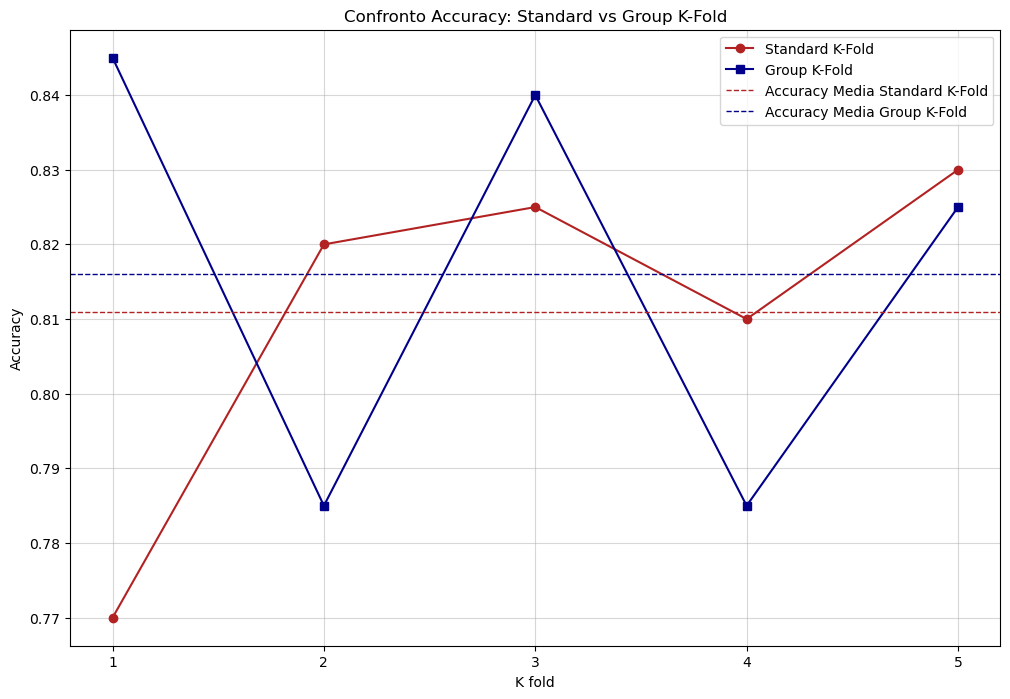

In [54]:
plt.figure(figsize=(12, 8))

plt.plot(np.arange(1, k + 1), accuracy_kf, marker='o', linestyle='-', color='firebrick', label='Standard K-Fold')
plt.plot(np.arange(1, k + 1), accuracy_gkf, marker='s', linestyle='-', color='darkblue', label='Group K-Fold')

plt.axhline(mean_kf, color='firebrick', linestyle='--', linewidth=1, label='Accuracy Media Standard K-Fold')
plt.axhline(mean_gkf, color='darkblue', linestyle='--', linewidth=1, label='Accuracy Media Group K-Fold')

plt.xticks(range(1, k + 1))

plt.title("Confronto Accuracy: Standard vs Group K-Fold")
plt.xlabel("K fold")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()